<a href="https://colab.research.google.com/github/2303a51019/Data-Analaysis/blob/main/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

if torch.cuda.is_available():
    print("CUDA is available! GPU Name:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available. Running on CPU.")

CUDA is available! GPU Name: Tesla T4


### Dataset Description (`.describe()`)

In [ ]:
display(titanic_df.describe())

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Column Names

In [ ]:
print(titanic_df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


### Mean of Numerical Columns (`.mean()`)

In [ ]:
display(titanic_df.mean(numeric_only=True))

,0
survived,0.383838
pclass,2.308642
age,29.699118
sibsp,0.523008
parch,0.381594
fare,32.204208
adult_male,0.602694
alone,0.602694


### Data Types (`.dtypes`)

In [ ]:
print(titanic_df.dtypes)

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


### Random Sample of 5 Rows (`.sample(5)`)

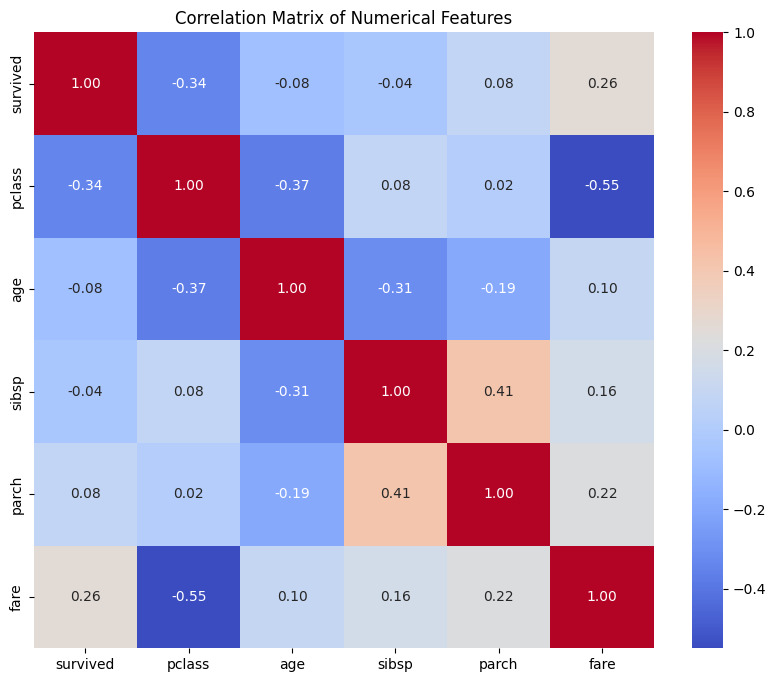

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation calculation
numerical_df = titanic_df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Next, let's look at the distribution of survival based on gender and passenger class. These are often strong predictors of survival.

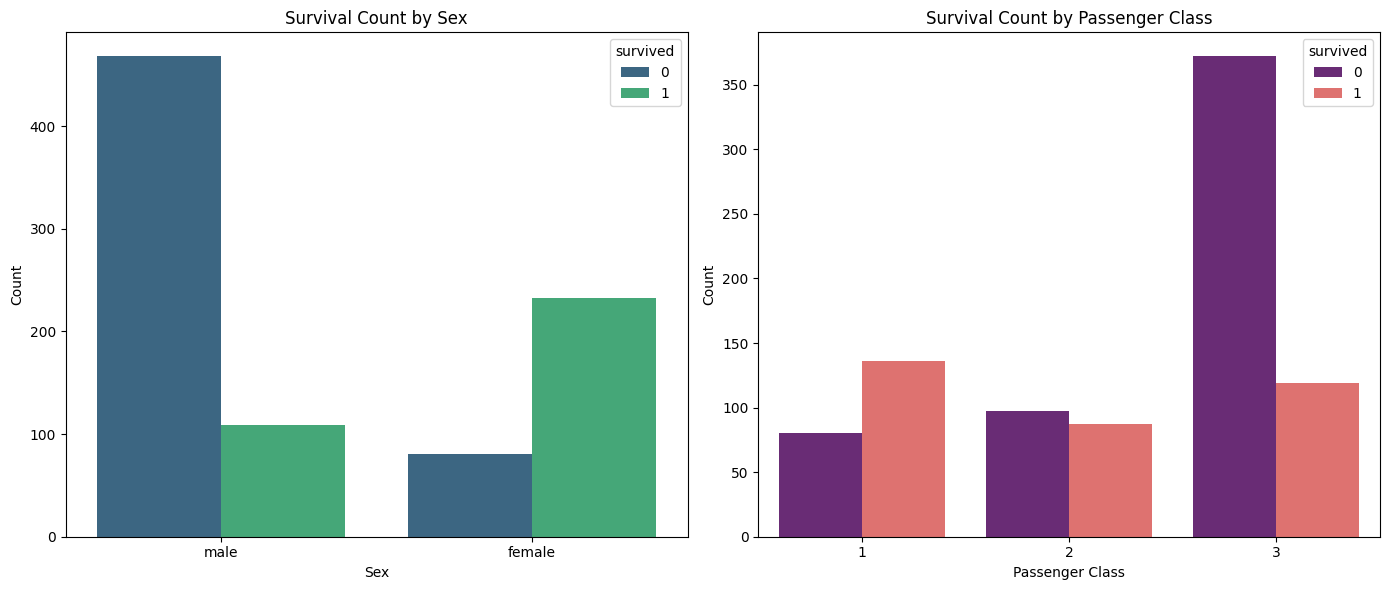

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='sex', hue='survived', data=titanic_df, palette='viridis', ax=axes[0])
axes[0].set_title('Survival Count by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

sns.countplot(x='pclass', hue='survived', data=titanic_df, palette='magma', ax=axes[1])
axes[1].set_title('Survival Count by Passenger Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Now, let's examine the distribution of 'Age' and 'Fare' and how they relate to survival.

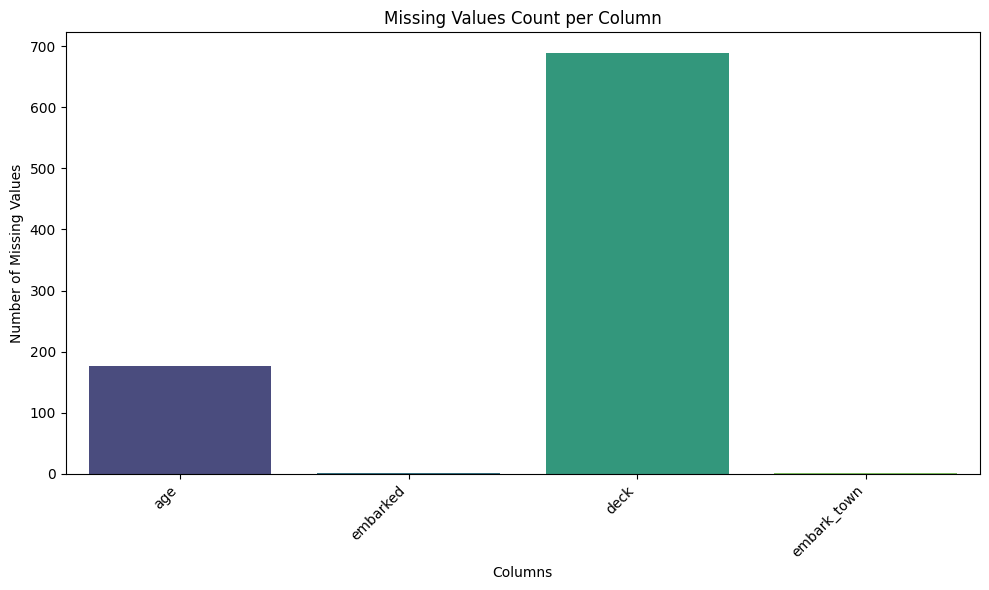

In [ ]:
missing_data = titanic_df.isnull().sum()
missing_data = missing_data[missing_data > 0]

if not missing_data.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y=missing_data.values, hue=missing_data.index, palette='viridis', legend=False)
    plt.title('Missing Values Count per Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the DataFrame.")

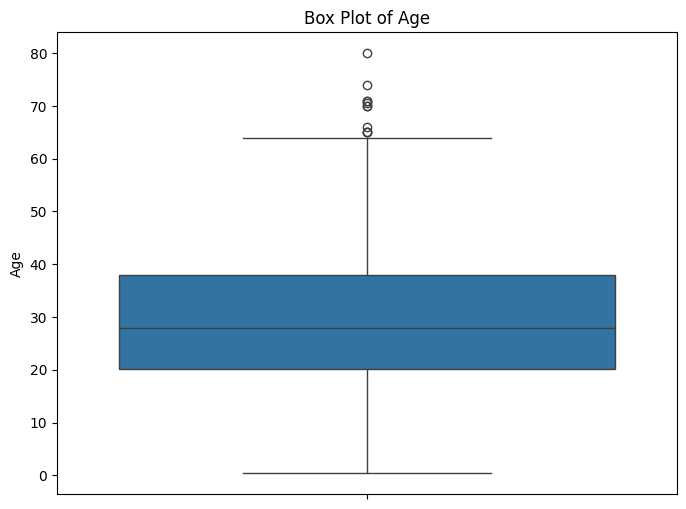

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=titanic_df['age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()

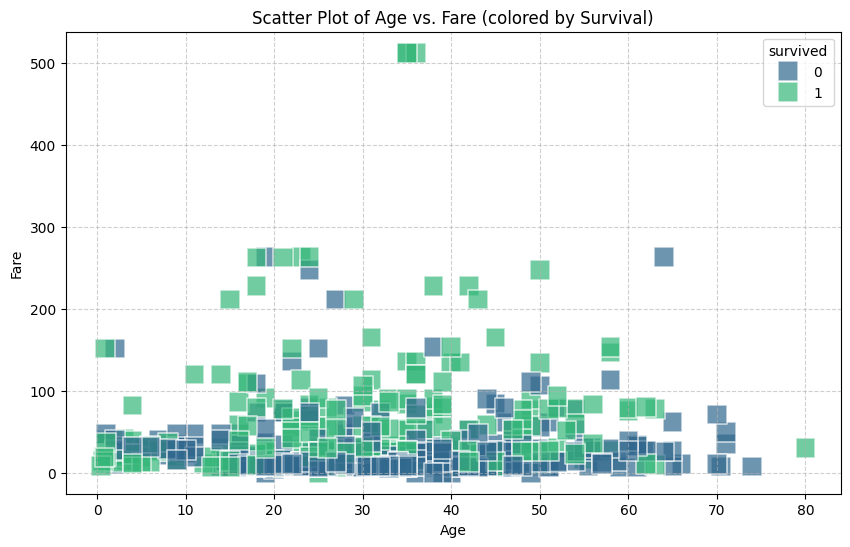

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='fare', data=titanic_df, hue='survived', palette='viridis', alpha=0.7, marker = "s" , s = 200)
plt.title('Scatter Plot of Age vs. Fare (colored by Survival)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer

# Drop 'deck' column due to a high percentage of missing values
titanic_df_processed = titanic_df.drop(columns=['deck'], errors='ignore')

# Impute missing 'age' values with the median
median_age_imputer = SimpleImputer(strategy='median')
titanic_df_processed['age'] = median_age_imputer.fit_transform(titanic_df_processed[['age']]).flatten()

# Impute missing 'embarked' and 'embark_town' values with the mode
mode_imputer = SimpleImputer(strategy='most_frequent')
titanic_df_processed['embarked'] = mode_imputer.fit_transform(titanic_df_processed[['embarked']]).flatten()
titanic_df_processed['embark_town'] = mode_imputer.fit_transform(titanic_df_processed[['embark_town']]).flatten()

print("Missing values after imputation:")
print(titanic_df_processed.isnull().sum())

Missing values after imputation:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


### Feature Selection and Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = titanic_df_processed.drop(columns=['survived', 'class', 'who', 'embark_town', 'alive', 'adult_male', 'alone'])
y = titanic_df_processed['survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

display(X_train.head())

Shape of X_train: (712, 8)
Shape of X_test: (179, 8)
Shape of y_train: (712,)
Shape of y_test: (179,)


,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
331,1,45.5,0,0,28.5000,1,0,1
733,2,23.0,0,0,13.0000,1,0,1
382,3,32.0,0,0,7.9250,1,0,1
704,3,26.0,1,0,7.8542,1,0,1
813,3,6.0,4,2,31.2750,0,0,1


Now that the data is split, we can proceed to train different machine learning models. I will start with a few common classification models such as Logistic Regression, Decision Tree, and Random Forest.

### Model Training and Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Dictionary to store results
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Evaluate model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 'N/A'

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}, ROC AUC: {roc_auc:.4f}")

display(pd.DataFrame(results).T)


Training Logistic Regression...
Logistic Regression - Accuracy: 0.7821, Precision: 0.7612, Recall: 0.6892, F1 Score: 0.7234, ROC AUC: 0.8779

Training Decision Tree...
Decision Tree - Accuracy: 0.7821, Precision: 0.7273, Recall: 0.7568, F1 Score: 0.7417, ROC AUC: 0.7982

Training Random Forest...
Random Forest - Accuracy: 0.8212, Precision: 0.8000, Recall: 0.7568, F1 Score: 0.7778, ROC AUC: 0.8869


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.782123,0.761194,0.689189,0.723404,0.877864
Decision Tree,0.782123,0.727273,0.756757,0.741722,0.798198
Random Forest,0.821229,0.800000,0.756757,0.777778,0.886873


### Visualizing Comprehensive Model Performance Metrics

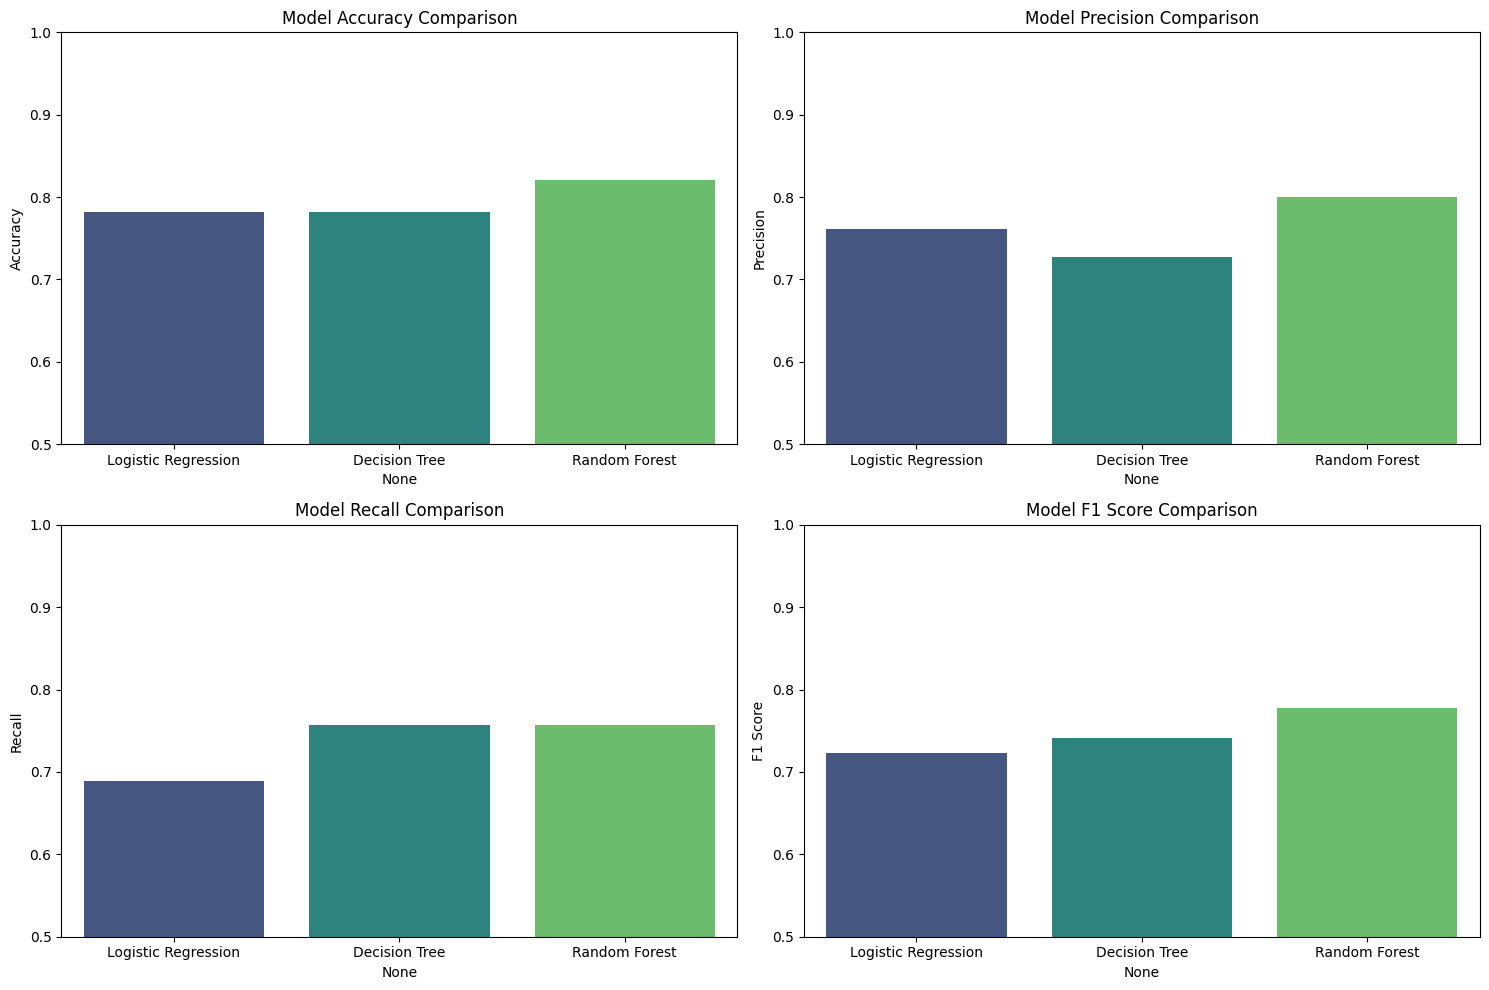

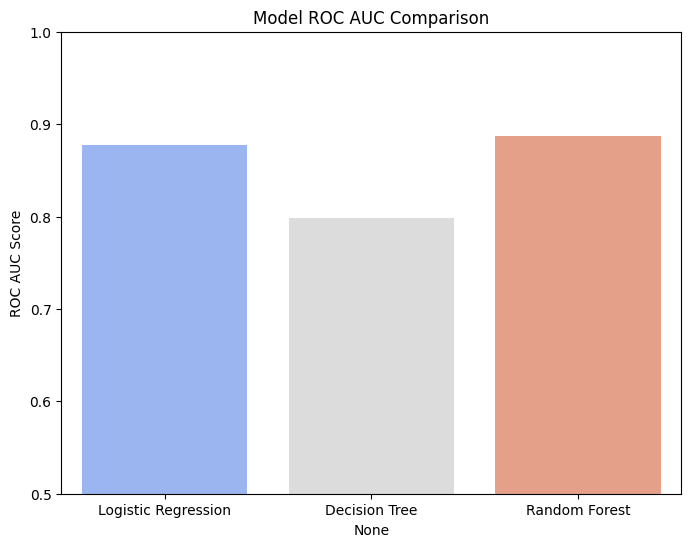

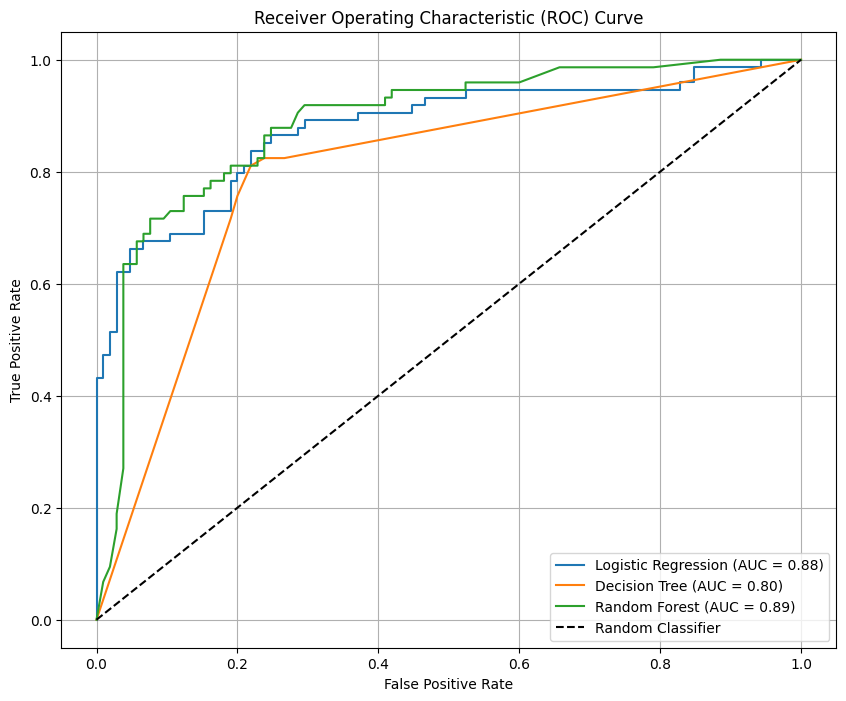

In [ ]:
from sklearn.metrics import roc_curve, RocCurveDisplay, auc

# Re-initialize models to get predict_proba for ROC curves
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Dictionary to store y_proba for ROC curve plotting
y_proba_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    if hasattr(model, 'predict_proba'):
        y_proba_dict[name] = model.predict_proba(X_test)[:, 1]

# Convert results to DataFrame for easier plotting (if not already updated)
results_df = pd.DataFrame(results).T

# Plotting Accuracy, Precision, Recall, F1 Score as bar plots
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.barplot(x=results_df.index, y=metric, data=results_df, palette='viridis', hue=results_df.index, legend=False)
    plt.title(f'Model {metric} Comparison')
    plt.ylabel(metric)
    plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

# Plotting ROC AUC as bar plot
if 'ROC AUC' in results_df.columns and results_df['ROC AUC'].dtype != object:
    plt.figure(figsize=(8, 6))
    sns.barplot(x=results_df.index, y='ROC AUC', data=results_df, palette='coolwarm', hue=results_df.index, legend=False)
    plt.title('Model ROC AUC Comparison')
    plt.ylabel('ROC AUC Score')
    plt.ylim(0.5, 1.0)
    plt.show()

# Plotting ROC Curves
plt.figure(figsize=(10, 8))
for name, y_proba in y_proba_dict.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

These plots provide a comprehensive view of how each classification model performs across various metrics:

*   **Accuracy:** The proportion of correctly classified instances.
*   **Precision:** The proportion of true positive predictions among all positive predictions.
*   **Recall (Sensitivity):** The proportion of true positive predictions among all actual positive instances.
*   **F1 Score:** The harmonic mean of precision and recall, providing a balanced measure.
*   **ROC AUC:** The Area Under the Receiver Operating Characteristic curve, indicating the model's ability to distinguish between classes across all possible classification thresholds.

The bar plots allow for a direct comparison of the scores for each metric across the different models. The ROC curve visually represents the trade-off between the true positive rate (sensitivity) and the false positive rate (1 - specificity) at various threshold settings. A curve that bends more towards the top-left corner indicates better performance, and a higher AUC score signifies a stronger predictive model.

Finally, let's visualize the performance of these models to compare them effectively.

### Comparative Analysis Visualization

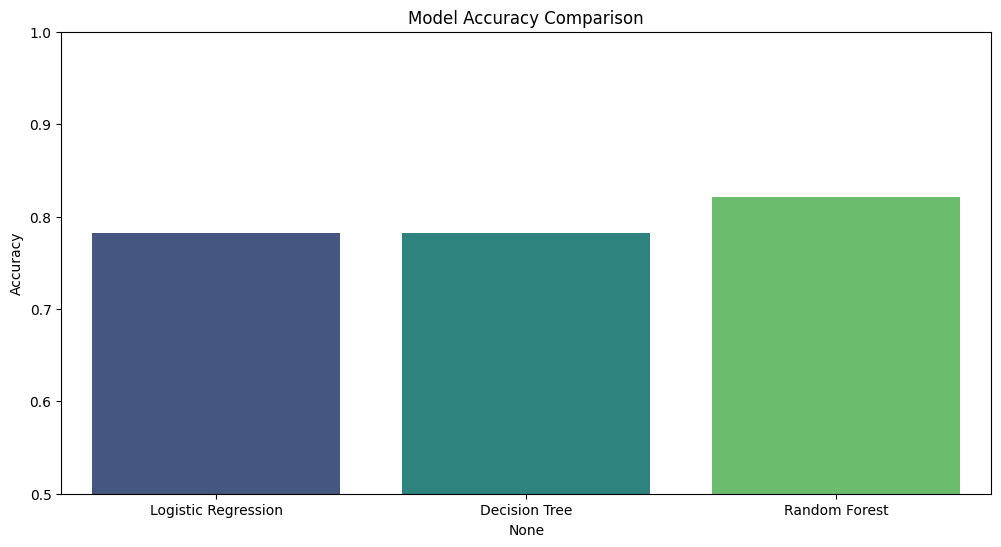

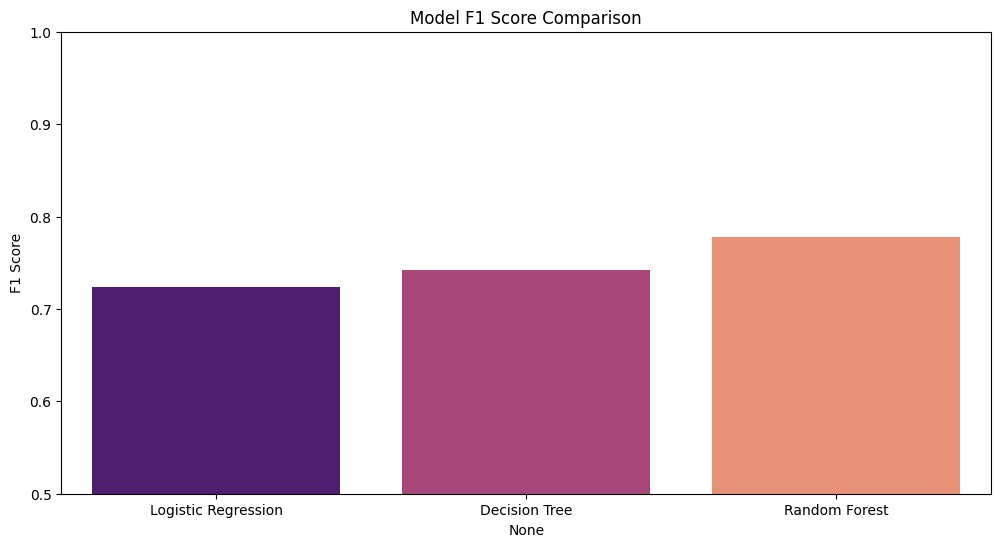

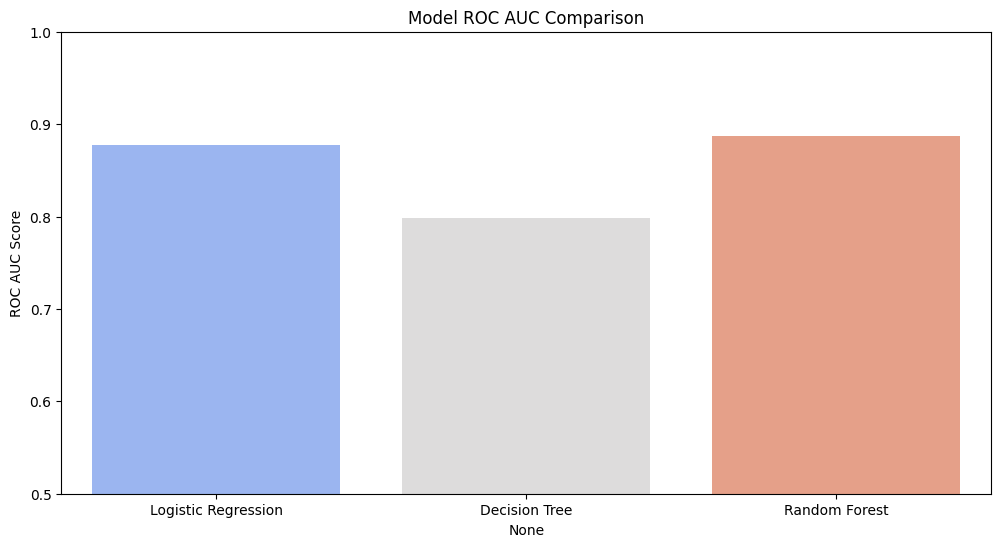

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert results to DataFrame for easier plotting
results_df = pd.DataFrame(results).T

# Plotting Accuracy
plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y='Accuracy', data=results_df, palette='viridis', hue=results_df.index, legend=False)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0) # Set a reasonable y-limit for accuracy
plt.show()

# Plotting F1 Score
plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y='F1 Score', data=results_df, palette='magma', hue=results_df.index, legend=False)
plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.ylim(0.5, 1.0)
plt.show()

# Plotting ROC AUC, if available
if 'ROC AUC' in results_df.columns and results_df['ROC AUC'].dtype != object: # Check if ROC AUC was calculated
    plt.figure(figsize=(12, 6))
    sns.barplot(x=results_df.index, y='ROC AUC', data=results_df, palette='coolwarm', hue=results_df.index, legend=False)
    plt.title('Model ROC AUC Comparison')
    plt.ylabel('ROC AUC Score')
    plt.ylim(0.5, 1.0)
    plt.show()

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer

# Drop 'deck' column due to a high percentage of missing values
titanic_df_processed = titanic_df.drop(columns=['deck'], errors='ignore')

# Impute missing 'age' values with the median
median_age_imputer = SimpleImputer(strategy='median')
titanic_df_processed['age'] = median_age_imputer.fit_transform(titanic_df_processed[['age']]).flatten()

# Impute missing 'embarked' and 'embark_town' values with the mode
mode_imputer = SimpleImputer(strategy='most_frequent')
titanic_df_processed['embarked'] = mode_imputer.fit_transform(titanic_df_processed[['embarked']]).flatten()
titanic_df_processed['embark_town'] = mode_imputer.fit_transform(titanic_df_processed[['embark_town']]).flatten()

print("Missing values after imputation:")
print(titanic_df_processed.isnull().sum())

Missing values after imputation:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [ ]:
# One-hot encode 'sex' and 'embarked' columns
titanic_df_processed = pd.get_dummies(titanic_df_processed, columns=['sex', 'embarked'], drop_first=True, dtype=int)

# Display the head of the processed DataFrame
display(titanic_df_processed.head())

# Display information about the processed DataFrame to check dtypes and non-null counts
print("\nInfo of the processed DataFrame:")
titanic_df_processed.info()

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,Third,man,True,Southampton,no,False,1,0,1
1,1,1,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False,0,0,0
2,1,3,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True,0,0,1
3,1,1,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False,0,0,1
4,0,3,35.0,0,0,8.0500,Third,man,True,Southampton,no,True,1,0,1



Info of the processed DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   age          891 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   class        891 non-null    category
 7   who          891 non-null    object  
 8   adult_male   891 non-null    bool    
 9   embark_town  891 non-null    object  
 10  alive        891 non-null    object  
 11  alone        891 non-null    bool    
 12  sex_male     891 non-null    int64   
 13  embarked_Q   891 non-null    int64   
 14  embarked_S   891 non-null    int64   
dtypes: bool(2), category(1), float64(2), int64(7), object(3)
memory usage: 86.4+ KB


In [ ]:
# One-hot encode 'sex' and 'embarked' columns
titanic_df_processed = pd.get_dummies(titanic_df_processed, columns=['sex', 'embarked'], drop_first=True, dtype=int)

# Display the head of the processed DataFrame
display(titanic_df_processed.head())

# Display information about the processed DataFrame to check dtypes and non-null counts
print("\nInfo of the processed DataFrame:")
titanic_df_processed.info()

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,Third,man,True,Southampton,no,False,1,0,1
1,1,1,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False,0,0,0
2,1,3,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True,0,0,1
3,1,1,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False,0,0,1
4,0,3,35.0,0,0,8.0500,Third,man,True,Southampton,no,True,1,0,1



Info of the processed DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   age          891 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   class        891 non-null    category
 7   who          891 non-null    object  
 8   adult_male   891 non-null    bool    
 9   embark_town  889 non-null    object  
 10  alive        891 non-null    object  
 11  alone        891 non-null    bool    
 12  sex_male     891 non-null    int64   
 13  embarked_Q   891 non-null    int64   
 14  embarked_S   891 non-null    int64   
dtypes: bool(2), category(1), float64(2), int64(7), object(3)
memory usage: 86.4+ KB


This scatter plot visualizes the relationship between a passenger's 'Age' and the 'Fare' they paid. The points are colored based on their 'Survived' status, which can help reveal if survival rates differ across age and fare combinations. For instance, you might observe clusters of survivors or non-survivors in specific age and fare ranges, indicating potential patterns.

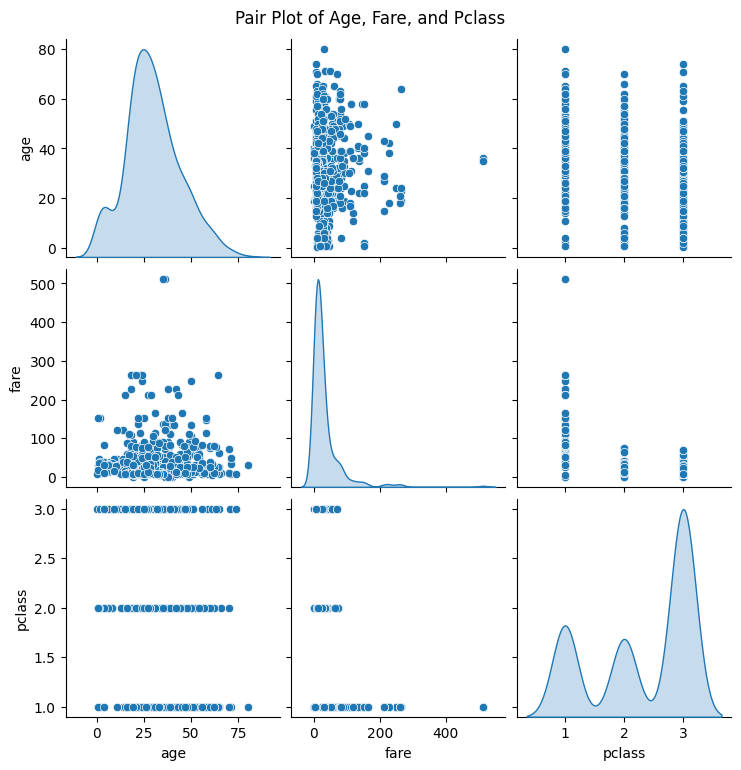

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pair plot for 'age', 'fare', and 'pclass'
sns.pairplot(titanic_df[['age', 'fare', 'pclass']], diag_kind='kde')
plt.suptitle('Pair Plot of Age, Fare, and Pclass', y=1.02) # Add a title to the plot
plt.show()

The pair plot above visualizes the relationships between 'age', 'fare', and 'pclass'.

*   **Diagonal plots (KDEs):** Show the distribution of each individual variable.
*   **Off-diagonal scatter plots:** Display the pairwise relationships between the variables. For example, you can observe how 'fare' changes with 'age', or how 'pclass' might relate to 'age' and 'fare'.

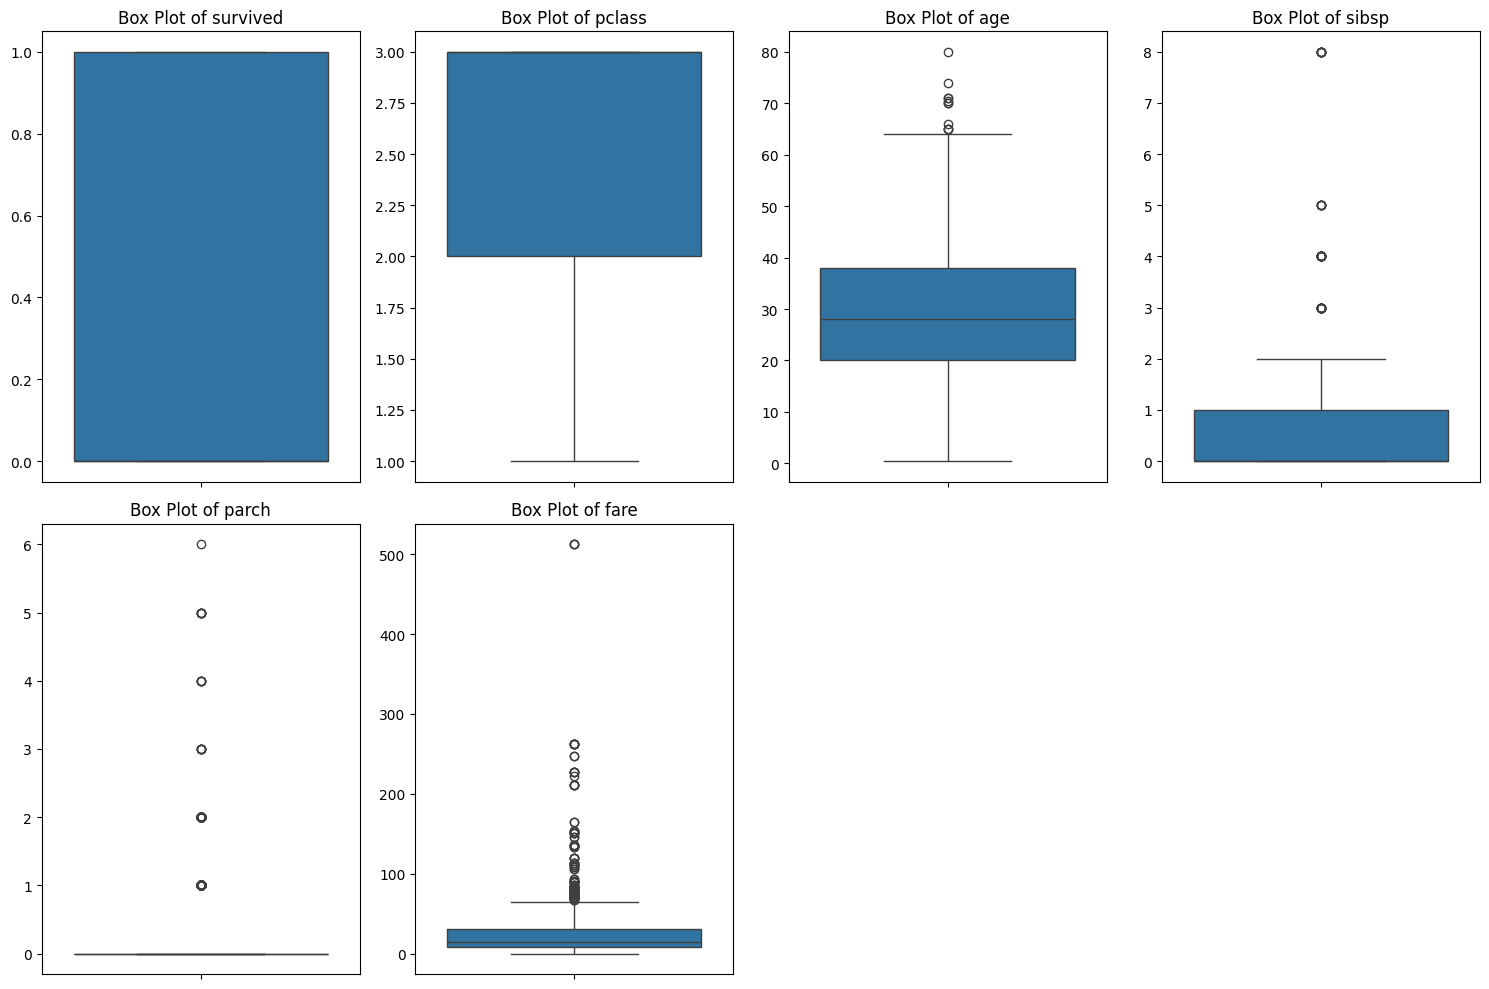

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for box plots
numerical_columns = titanic_df.select_dtypes(include=['number']).columns

# Create a box plot for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 4, i)  # Adjust subplot grid as needed
    sns.boxplot(y=titanic_df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove y-label as it's repetitive
plt.tight_layout()
plt.show()

The box plots above show the distribution of numerical features in the Titanic dataset. Key observations include:

*   **Age:** Shows a relatively wide distribution with some outliers, indicating older passengers.
*   **Fare:** Highly skewed distribution with many outliers, reflecting a few passengers who paid very high fares.
*   **SibSp (Siblings/Spouses Aboard) & Parch (Parents/Children Aboard):** Most passengers traveled alone or with one or two family members, with a few outliers having larger families.
*   **Survived & Pclass:** These are categorical but represented as numbers. The box plots show their distribution, with `Survived` indicating the proportion of survivors and `Pclass` showing the distribution across the three passenger classes.

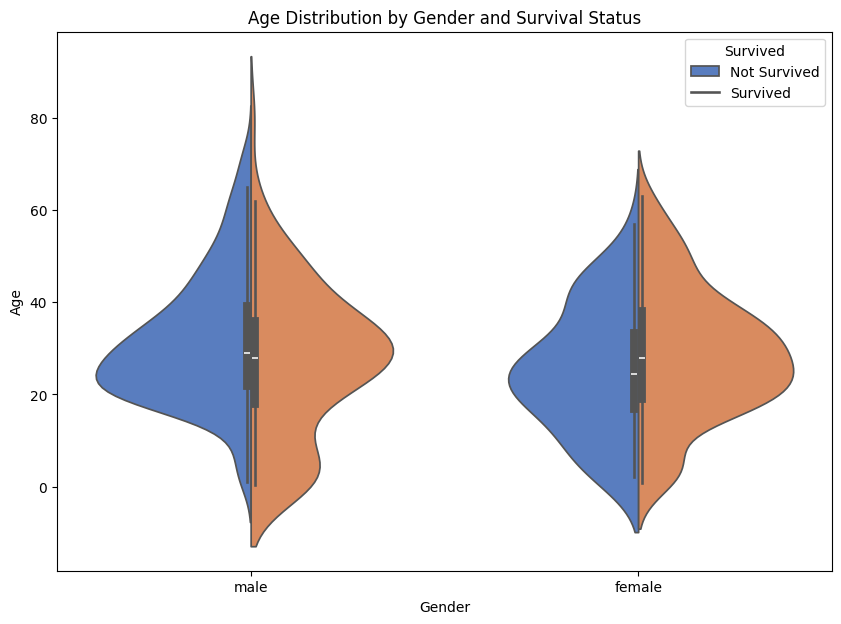

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.violinplot(x='sex', y='age', hue='survived', data=titanic_df, palette='muted', split=True)
plt.title('Age Distribution by Gender and Survival Status')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.legend(title='Survived', labels=['Not Survived', 'Survived'])
plt.show()

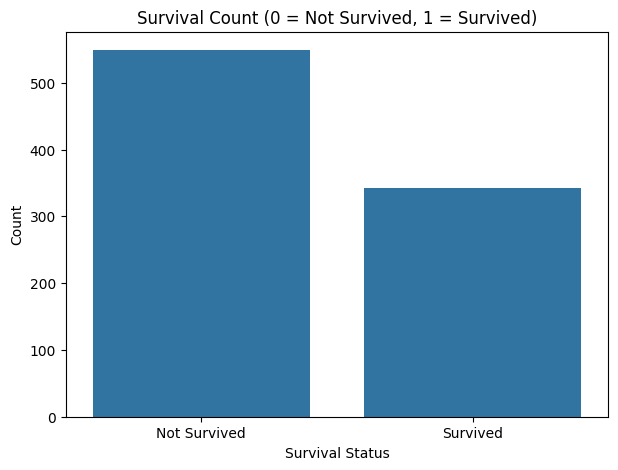

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='survived', data=titanic_df)
plt.title('Survival Count (0 = Not Survived, 1 = Survived)')
plt.xlabel('Survival Status')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Not Survived', 'Survived'])
plt.show()

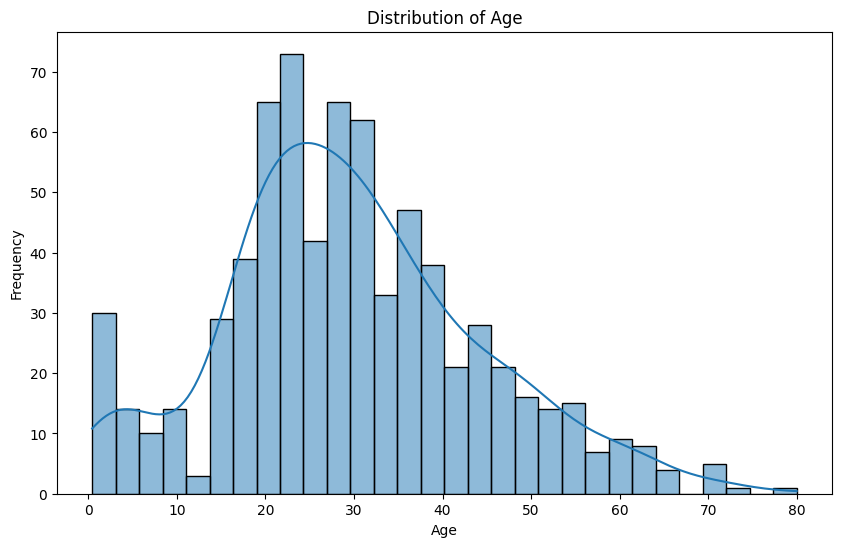

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(titanic_df['age'].dropna(), kde=True, bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

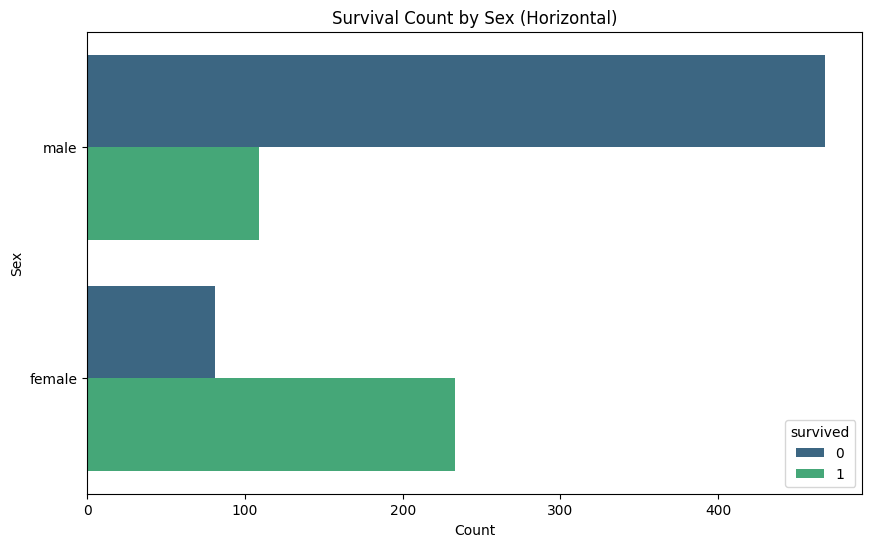

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(y='sex', hue='survived', data=titanic_df, palette='viridis')
plt.title('Survival Count by Sex (Horizontal)')
plt.xlabel('Count')
plt.ylabel('Sex')
plt.show()

### Survival Count by Embarkation Port

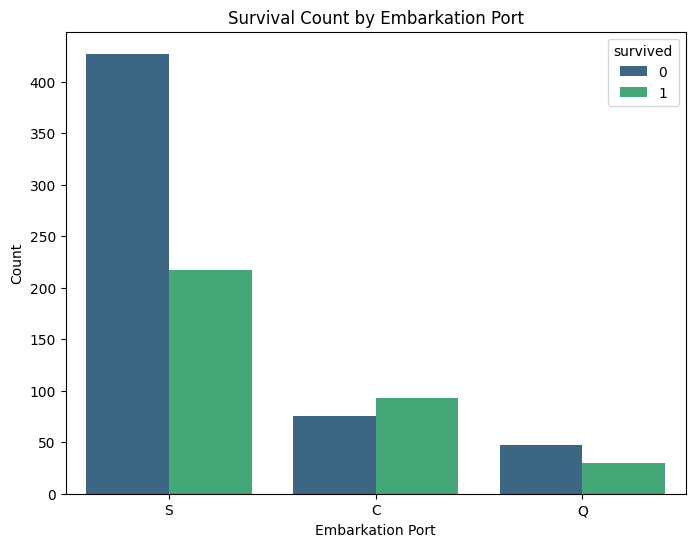

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='embarked', hue='survived', data=titanic_df, palette='viridis')
plt.title('Survival Count by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Count')
plt.show()

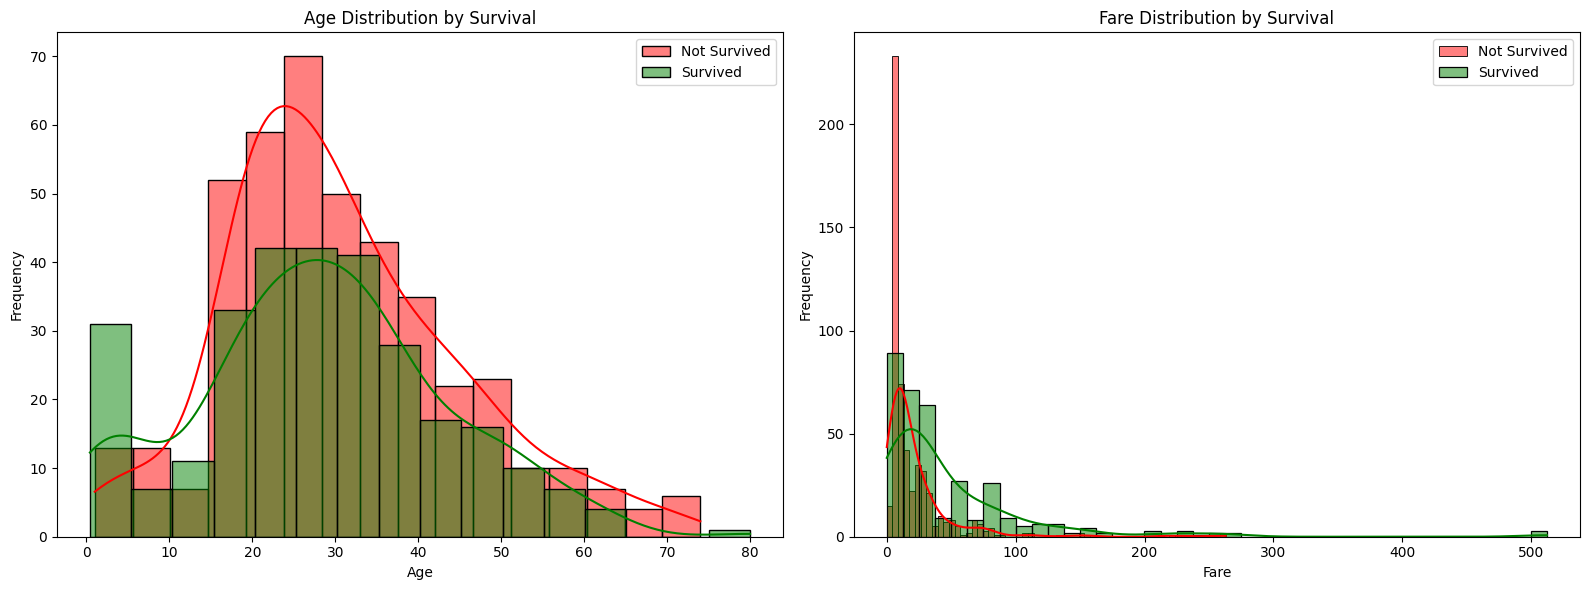

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(titanic_df[titanic_df['survived'] == 0]['age'].dropna(), kde=True, color='red', label='Not Survived', ax=axes[0])
sns.histplot(titanic_df[titanic_df['survived'] == 1]['age'].dropna(), kde=True, color='green', label='Survived', ax=axes[0])
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.histplot(titanic_df[titanic_df['survived'] == 0]['fare'].dropna(), kde=True, color='red', label='Not Survived', ax=axes[1])
sns.histplot(titanic_df[titanic_df['survived'] == 1]['fare'].dropna(), kde=True, color='green', label='Survived', ax=axes[1])
axes[1].set_title('Fare Distribution by Survival')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
display(titanic_df[titanic_df['age'] > 35])

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
13,0,3,male,39.0,1,5,31.2750,S,Third,man,True,NaN,Southampton,no,False
15,1,2,female,55.0,0,0,16.0000,S,Second,woman,False,NaN,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
865,1,2,female,42.0,0,0,13.0000,S,Second,woman,False,NaN,Southampton,yes,True
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
873,0,3,male,47.0,0,0,9.0000,S,Third,man,True,NaN,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False


In [ ]:
display(titanic_df['age'])

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [ ]:
selected_columns = ['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']
display(titanic_df[selected_columns].head())

,survived,pclass,sex,age,fare,embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [ ]:
display(titanic_df.sample(5))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
626,0,2,male,57.0,0,0,12.3500,Q,Second,man,True,NaN,Queenstown,no,True
377,0,1,male,27.0,0,2,211.5000,C,First,man,True,C,Cherbourg,no,False
46,0,3,male,NaN,1,0,15.5000,Q,Third,man,True,NaN,Queenstown,no,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
452,0,1,male,30.0,0,0,27.7500,C,First,man,True,C,Cherbourg,no,True


In [ ]:
import seaborn as sns
import pandas as pd

titanic_df = sns.load_dataset('titanic')
display(titanic_df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
import seaborn as sns

print("Seaborn is imported.")

Seaborn is imported.


In [ ]:
print("Available Seaborn datasets:")
print(sns.get_dataset_names())

Available Seaborn datasets:
['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']
